In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import numpy as np

data = np.array([
    [2, 3],   # A
    [3, 4],   # B
    [10, 11], # C
    [11, 12]  # D
])

In [ ]:
def distance_matrix(data):
    n = len(data)
    matrix = np.zeros((n,n))

    for i in range(n):
        for j in range(n):
            matrix[i][j] = np.linalg.norm(data[i] - data[j])

    return matrix

print(distance_matrix(data))

[[ 0.          1.41421356 11.3137085  12.72792206]
 [ 1.41421356  0.          9.89949494 11.3137085 ]
 [11.3137085   9.89949494  0.          1.41421356]
 [12.72792206 11.3137085   1.41421356  0.        ]]


In [ ]:
def euclidean(p1, p2):
    return np.linalg.norm(p1 - p2)


def cluster_distance(c1, c2, data):
    min_dist = float('inf')

    for i in c1:
        for j in c2:
            d = euclidean(data[i], data[j])
            if d < min_dist:
                min_dist = d

    return min_dist


def hierarchical_clustering(data):

    clusters = [[i] for i in range(len(data))]

    step = 1

    while len(clusters) > 1:

        min_dist = float('inf')
        merge_i, merge_j = None, None

        # find closest clusters
        for i in range(len(clusters)):
            for j in range(i+1, len(clusters)):

                d = cluster_distance(clusters[i], clusters[j], data)

                if d < min_dist:
                    min_dist = d
                    merge_i, merge_j = i, j

        print("Step", step)
        print("Merging clusters:", clusters[merge_i], "and", clusters[merge_j])
        print("Distance:", min_dist)

        new_cluster = clusters[merge_i] + clusters[merge_j]

        clusters.pop(merge_j)
        clusters.pop(merge_i)

        clusters.append(new_cluster)

        print("Clusters:", clusters)
        print()

        step += 1

    return clusters

In [ ]:
hierarchical_clustering(data)

Step 1
Merging clusters: [0] and [1]
Distance: 1.4142135623730951
Clusters: [[2], [3], [0, 1]]

Step 2
Merging clusters: [2] and [3]
Distance: 1.4142135623730951
Clusters: [[0, 1], [2, 3]]

Step 3
Merging clusters: [0, 1] and [2, 3]
Distance: 9.899494936611665
Clusters: [[0, 1, 2, 3]]



[[0, 1, 2, 3]]

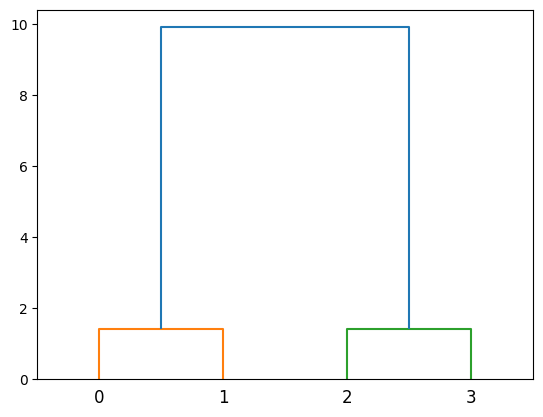

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

Z = linkage(data, method='single')

dendrogram(Z)

plt.show()